**Crossing Detector Data**\
TODO: Make a general data loading script

In [1]:
from glob import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.close('all')

In [2]:
folder = 'C:\\Users\\Leah\\Documents\\OnixData\\CrossingDetectorTesting\\Event_Duration_Test3\\'

suffix = '0'

**Metadata**

In [3]:
dtMeta = {'names': ('time', 'acq_clk_hz', 'block_read_sz', 'block_write_sz'),
      'formats': ('datetime64[us]', 'u4', 'u4', 'u4')}
meta = np.genfromtxt(folder + 'start-time_' + suffix + '.csv', delimiter=',', dtype=dtMeta)
print(f"Recording was started at {meta['time']} GMT")

Recording was started at 2025-06-03T22:04:57.918144 GMT


**Analog Inputs**

In [4]:
analog_input = {}
analog_input['time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64) / meta['acq_clk_hz']
analog_input['data'] = np.reshape(np.fromfile(folder + 'analog-data_' + suffix + '.raw', dtype=np.float32), (-1, 12))

**Crossing Detector TTL Out**

In [5]:
dtTTL = {'names': ('time', 'word_out'),
      'formats': ('datetime64[us]', 'u4')}
ttl = np.genfromtxt(folder + 'TTL-time_' + suffix + '.csv', delimiter=',', dtype=dtTTL)
print(f"First TTL out was at {ttl['time'][0]} GMT and was {ttl['word_out'][0]}")

First TTL out was at 2025-06-03T22:04:57.923750 GMT and was 0


**Plots**

In [6]:
%matplotlib widget

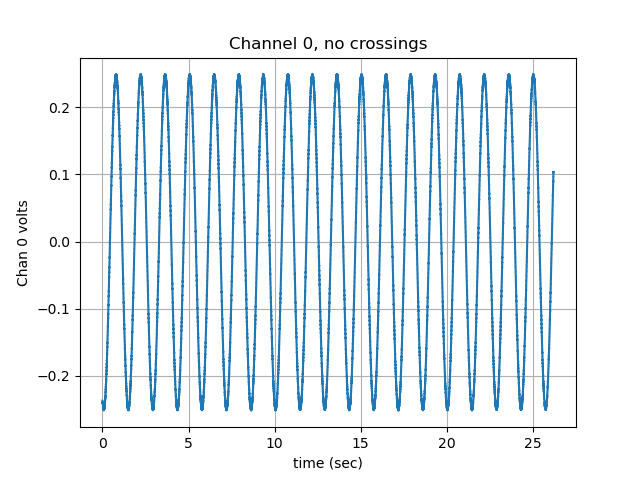

In [7]:
min_len = min(len(analog_input['time']), analog_input['data'].shape[0])
time = analog_input['time']#[:min_len]
channel_0 = analog_input['data'][:,0]#[:min_len, 0]

plt.figure()
plt.title("Channel 0, no crossings")
plt.plot(time, channel_0)
plt.xlabel("time (sec)")
plt.ylabel("Chan 0 volts")
plt.grid(True)
plt.show()


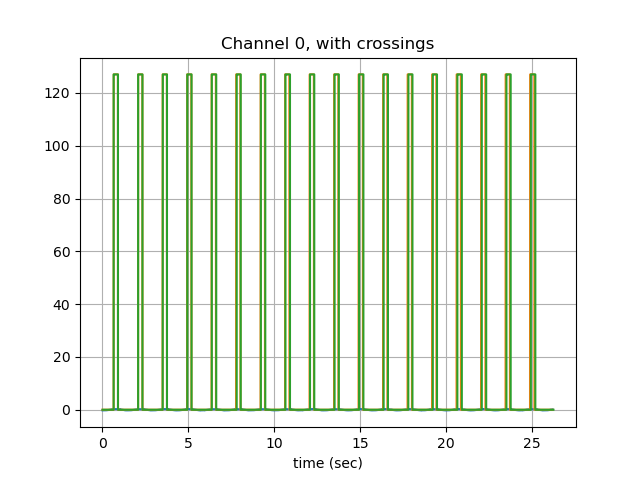

In [8]:
sync_time = (ttl['time'] - meta['time'])
s = sync_time.astype(np.float64, casting='unsafe') / 1e6

# min_len_ttl = min(len(s), len(ttl['word_out']))
# s = s[:min_len_ttl]
word_out = ttl['word_out']#[:min_len_ttl]

plt.figure()
plt.title("Channel 0, with crossings")
plt.plot(time, channel_0)
plt.plot(time, word_out)
plt.plot(s, word_out)
plt.xlabel("time (sec)")
plt.grid(True)
plt.show()




C:\Users\Leah\AppData\Local\Temp\ipykernel_40364\2206978988.py:2: RuntimeWarning: divide by zero encountered in true_divide
  srate = 1/timeDif


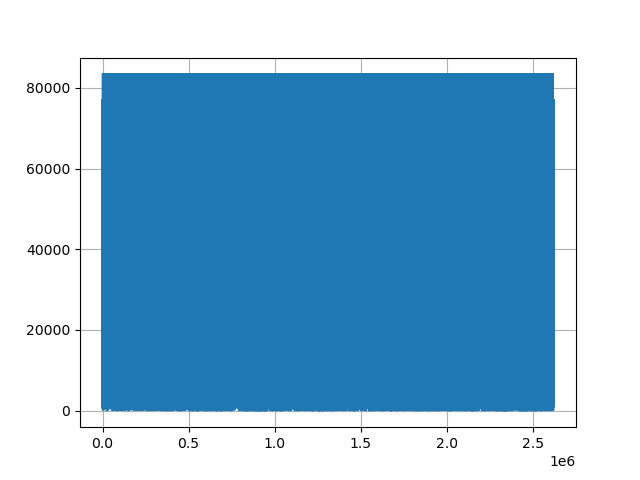

In [9]:

timeDif = s[2:] - s[1:-1]
srate = 1/timeDif

plt.figure()
plt.plot(srate)
plt.grid(True)
plt.show()

In [10]:
sync_time

array([    5606,     5606,     5619, ..., 26251020, 26251020, 26251020],
      dtype='timedelta64[us]')